# Neural Network Emulator for Synthetic Heston Implied Volatility Data

This notebook trains a neural network using the synthetic data generated by your Heston data notebook.

The synthetic-data notebook creates a table where each row looks like:

```text
[v0, kappa, theta, sigma_v, rho, moneyness, maturity]  →  implied_vol
```

So the neural network learns the mapping:

$$
(v_0,\kappa,\theta,\sigma_v,\rho,K/S_0,T)
\longmapsto
\sigma_{\mathrm{IV}}.
$$

This is an **emulator** for the Heston implied-volatility surface.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 1. Load the synthetic dataset

Your synthetic-data notebook saves:

```text
data/synthetic_heston_iv.csv
```

Run the synthetic-data notebook first if this file does not exist.

If your file is somewhere else, edit `DATA_PATH`.


In [2]:
DATA_PATH = Path("data/synthetic_heston_iv.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Run the synthetic-data notebook first, or edit DATA_PATH to point to the CSV."
    )

df = pd.read_csv(DATA_PATH)

print("Rows:", len(df))
print("Columns:")
print(df.columns.tolist())

df.head()


Rows: 182016
Columns:
['parameter_set_id', 'v0', 'kappa', 'theta', 'sigma_v', 'rho', 'feller_margin', 'strike', 'moneyness', 'maturity', 'call_price', 'implied_vol']


,parameter_set_id,v0,kappa,theta,sigma_v,rho,feller_margin,strike,moneyness,maturity,call_price,implied_vol
0,0,0.074996,2.1533,0.187783,0.297192,-0.273026,0.720382,95.0,0.95,0.005479,5.019753,0.278984
1,0,0.074996,2.1533,0.187783,0.297192,-0.273026,0.720382,100.0,1.00,0.005479,0.820449,0.275061
2,0,0.074996,2.1533,0.187783,0.297192,-0.273026,0.720382,105.0,1.05,0.005479,0.005310,0.271681
3,0,0.074996,2.1533,0.187783,0.297192,-0.273026,0.720382,90.0,0.90,0.010959,10.029724,0.284981
4,0,0.074996,2.1533,0.187783,0.297192,-0.273026,0.720382,95.0,0.95,0.010959,5.076309,0.280167


## 2. Clean and inspect the data

We only keep rows with finite positive implied volatility.


In [3]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

df = df[df["implied_vol"] > 0.0].copy()

print("Rows after cleaning:", len(df))
print()
print(df.describe())


Rows after cleaning: 182016

       parameter_set_id             v0          kappa          theta  \
count     182016.000000  182016.000000  182016.000000  182016.000000   
mean         749.337058       0.136397       2.552933       0.130022   
std          432.661768       0.068074       1.414592       0.069401   
min            0.000000       0.010021       0.100106       0.010123   
25%          375.000000       0.079203       1.326146       0.069824   
50%          748.000000       0.139002       2.556900       0.130206   
75%         1125.000000       0.195377       3.777291       0.190120   
max         1499.000000       0.249892       4.998386       0.249924   

             sigma_v            rho  feller_margin         strike  \
count  182016.000000  182016.000000  182016.000000  182016.000000   
mean        0.527900      -0.472325       0.312386      99.877373   
std         0.274319       0.273219       0.633422      17.464499   
min         0.050200      -0.949577      -0.95

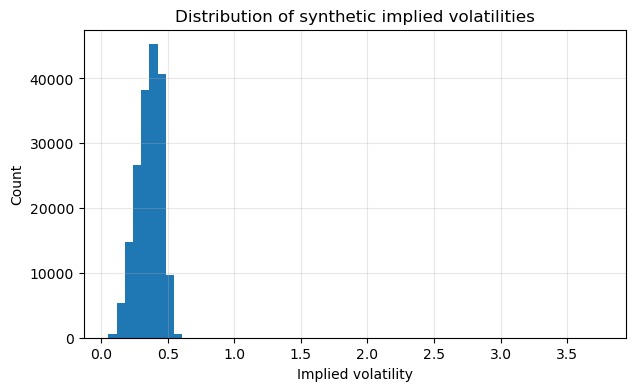

In [4]:
plt.figure(figsize=(7, 4))
plt.hist(df["implied_vol"], bins=60)
plt.xlabel("Implied volatility")
plt.ylabel("Count")
plt.title("Distribution of synthetic implied volatilities")
plt.grid(alpha=0.3)
plt.show()


## 3. Choose input features and target

The inputs are the Heston parameters plus the option location on the surface:

$$
[v_0,\kappa,\theta,\sigma_v,\rho,\text{moneyness},T].
$$

The target is:

$$
\text{implied volatility}.
$$


In [5]:
feature_columns = [
    "v0",
    "kappa",
    "theta",
    "sigma_v",
    "rho",
    "moneyness",
    "maturity",
]

target_column = "implied_vol"

X_raw = df[feature_columns].to_numpy(dtype=np.float32)
y_raw = df[[target_column]].to_numpy(dtype=np.float32)

print("X shape:", X_raw.shape)
print("y shape:", y_raw.shape)

print("\nFirst input row:")
for name, value in zip(feature_columns, X_raw[0]):
    print(f"{name:10s}: {value:.6f}")

print("\nFirst target implied vol:", y_raw[0, 0])


X shape: (182016, 7)
y shape: (182016, 1)

First input row:
v0        : 0.074996
kappa     : 2.153300
theta     : 0.187783
sigma_v   : 0.297192
rho       : -0.273026
moneyness : 0.950000
maturity  : 0.005479

First target implied vol: 0.27898392


## 4. Train / validation / test split

We split by `parameter_set_id`, not by individual rows.

This matters because each Heston parameter set appears many times, once for each moneyness and maturity. If we split individual rows randomly, the network could see the same Heston parameter set during training and testing, which would make the test set too easy.

Splitting by `parameter_set_id` gives a better test of whether the network generalizes to new Heston parameter combinations.


In [6]:
unique_parameter_sets = df["parameter_set_id"].unique()

train_ids, holdout_ids = train_test_split(
    unique_parameter_sets,
    test_size=0.20,
    random_state=42,
)

val_ids, test_ids = train_test_split(
    holdout_ids,
    test_size=0.50,
    random_state=42,
)

train_mask = df["parameter_set_id"].isin(train_ids).to_numpy()
val_mask = df["parameter_set_id"].isin(val_ids).to_numpy()
test_mask = df["parameter_set_id"].isin(test_ids).to_numpy()

X_train_raw = X_raw[train_mask]
y_train_raw = y_raw[train_mask]

X_val_raw = X_raw[val_mask]
y_val_raw = y_raw[val_mask]

X_test_raw = X_raw[test_mask]
y_test_raw = y_raw[test_mask]

print("Training rows:", X_train_raw.shape[0])
print("Validation rows:", X_val_raw.shape[0])
print("Test rows:", X_test_raw.shape[0])

print("\nTraining parameter sets:", len(train_ids))
print("Validation parameter sets:", len(val_ids))
print("Test parameter sets:", len(test_ids))


Training rows: 145314
Validation rows: 18103
Test rows: 18599

Training parameter sets: 1200
Validation parameter sets: 150
Test parameter sets: 150


## 5. Standardize inputs and target

The input variables have very different scales. For example, maturity is often much smaller than $\kappa$, and $\rho$ is negative.

We standardize using the training set only:

$$
x_{\mathrm{scaled}} = \frac{x-\mu_{\mathrm{train}}}{s_{\mathrm{train}}}.
$$

We also standardize implied volatility so the neural network trains more smoothly.


In [7]:
X_mean = X_train_raw.mean(axis=0, keepdims=True)
X_std = X_train_raw.std(axis=0, keepdims=True)
X_std = np.maximum(X_std, 1e-8)

y_mean = y_train_raw.mean(axis=0, keepdims=True)
y_std = y_train_raw.std(axis=0, keepdims=True)
y_std = np.maximum(y_std, 1e-8)

X_train = (X_train_raw - X_mean) / X_std
X_val = (X_val_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

y_train = (y_train_raw - y_mean) / y_std
y_val = (y_val_raw - y_mean) / y_std
y_test = (y_test_raw - y_mean) / y_std

print("Input mean:")
for name, value in zip(feature_columns, X_mean.ravel()):
    print(f"{name:10s}: {value:.6f}")

print("\nInput std:")
for name, value in zip(feature_columns, X_std.ravel()):
    print(f"{name:10s}: {value:.6f}")

print("\nTarget mean:", y_mean.item())
print("Target std:", y_std.item())


Input mean:
v0        : 0.134741
kappa     : 2.573805
theta     : 0.129754
sigma_v   : 0.528030
rho       : -0.468415
moneyness : 0.998692
maturity  : 0.226990

Input std:
v0        : 0.067734
kappa     : 1.418653
theta     : 0.069015
sigma_v   : 0.272987
rho       : 0.275064
moneyness : 0.174570
maturity  : 0.304241

Target mean: 0.3583885729312897
Target std: 0.09243381768465042


## 6. Convert arrays to PyTorch tensors

Each row is one option point on one implied-volatility surface.


In [8]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

batch_size = 512

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

print("One input has", X_train_tensor.shape[1], "features.")
print("One output has", y_train_tensor.shape[1], "number: implied volatility.")


One input has 7 features.
One output has 1 number: implied volatility.


## 7. Define the neural network

This is a standard fully connected regression network.

The output layer has one number because the target is one implied volatility value.


In [9]:
class HestonIVNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.model(x)


net = HestonIVNet(n_features=X_train_tensor.shape[1]).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

print(net)


HestonIVNet(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 8. Train the network

The loss is mean squared error in standardized implied-volatility space.

After training, we convert the predictions back to ordinary implied-volatility units.


In [10]:
n_epochs = 200

train_loss_history = []
val_loss_history = []

best_val_loss = np.inf
best_state_dict = None

for epoch in range(1, n_epochs + 1):
    net.train()

    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred_batch = net(X_batch)
        train_loss = loss_fn(y_pred_batch, y_batch)

        train_loss.backward()
        optimizer.step()

        total_train_loss += train_loss.item() * X_batch.shape[0]

    average_train_loss = total_train_loss / len(train_loader.dataset)

    net.eval()
    with torch.no_grad():
        y_val_pred = net(X_val_tensor)
        average_val_loss = loss_fn(y_val_pred, y_val_tensor).item()

    train_loss_history.append(average_train_loss)
    val_loss_history.append(average_val_loss)

    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_state_dict = {key: value.detach().cpu().clone() for key, value in net.state_dict().items()}

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"train loss = {average_train_loss:.6f} | "
            f"validation loss = {average_val_loss:.6f}"
        )

net.load_state_dict(best_state_dict)
print("\nLoaded best validation-loss model.")
print("Best validation loss:", best_val_loss)


Epoch   1 | train loss = 0.109465 | validation loss = 0.010596
Epoch  10 | train loss = 0.042115 | validation loss = 0.005152
Epoch  20 | train loss = 0.033909 | validation loss = 0.002023
Epoch  30 | train loss = 0.028792 | validation loss = 0.001761
Epoch  40 | train loss = 0.026089 | validation loss = 0.001823
Epoch  50 | train loss = 0.025218 | validation loss = 0.001812
Epoch  60 | train loss = 0.023330 | validation loss = 0.002085
Epoch  70 | train loss = 0.026845 | validation loss = 0.001667
Epoch  80 | train loss = 0.024813 | validation loss = 0.003441
Epoch  90 | train loss = 0.030718 | validation loss = 0.001863
Epoch 100 | train loss = 0.021091 | validation loss = 0.002281
Epoch 110 | train loss = 0.020257 | validation loss = 0.001382
Epoch 120 | train loss = 0.018399 | validation loss = 0.001243
Epoch 130 | train loss = 0.019031 | validation loss = 0.001152
Epoch 140 | train loss = 0.019418 | validation loss = 0.001693
Epoch 150 | train loss = 0.017187 | validation loss = 0

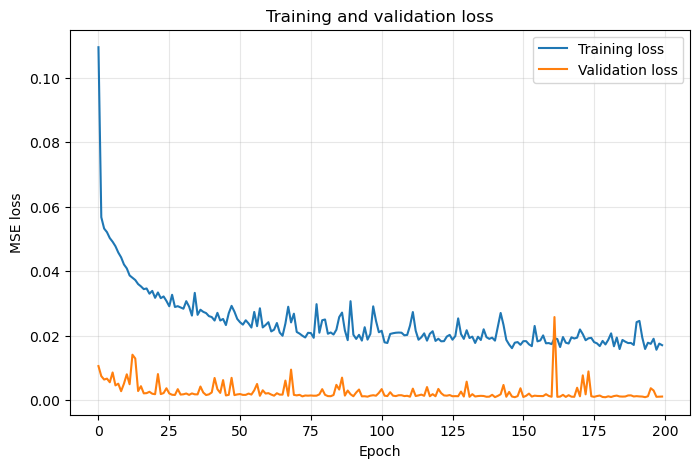

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="Training loss")
plt.plot(val_loss_history, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 9. Prediction helper

This function returns implied-volatility predictions in ordinary, unstandardized units.


In [12]:
def predict_implied_volatility(model, X_raw_input):
    """
    Predict implied volatility from raw input features.

    X_raw_input should have columns:
    [v0, kappa, theta, sigma_v, rho, moneyness, maturity]
    """
    X_raw_input = np.asarray(X_raw_input, dtype=np.float32)

    if X_raw_input.ndim == 1:
        X_raw_input = X_raw_input.reshape(1, -1)

    X_scaled_input = (X_raw_input - X_mean) / X_std
    X_tensor = torch.tensor(X_scaled_input, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        y_scaled_pred = model(X_tensor).cpu().numpy()

    y_pred = y_scaled_pred * y_std + y_mean
    return y_pred


## 10. Inspect individual validation predictions

These examples compare the true synthetic implied volatility to the neural-network prediction.


In [13]:
n_show = 10

val_pred = predict_implied_volatility(net, X_val_raw[:n_show])

for i in range(n_show):
    print("\n" + "=" * 72)

    for name, value in zip(feature_columns, X_val_raw[i]):
        print(f"{name:10s}: {value:.6f}")

    print(f"true IV     : {y_val_raw[i, 0]:.6f}")
    print(f"predicted IV: {val_pred[i, 0]:.6f}")
    print(f"error       : {val_pred[i, 0] - y_val_raw[i, 0]:+.6f}")



v0        : 0.066595
kappa     : 3.643374
theta     : 0.219494
sigma_v   : 0.728581
rho       : -0.886530
moneyness : 0.900000
maturity  : 0.005479
true IV     : 0.313061
predicted IV: 0.310353
error       : -0.002708

v0        : 0.066595
kappa     : 3.643374
theta     : 0.219494
sigma_v   : 0.728581
rho       : -0.886530
moneyness : 0.950000
maturity  : 0.005479
true IV     : 0.289243
predicted IV: 0.286093
error       : -0.003150

v0        : 0.066595
kappa     : 3.643374
theta     : 0.219494
sigma_v   : 0.728581
rho       : -0.886530
moneyness : 1.000000
maturity  : 0.005479
true IV     : 0.260699
predicted IV: 0.260226
error       : -0.000473

v0        : 0.066595
kappa     : 3.643374
theta     : 0.219494
sigma_v   : 0.728581
rho       : -0.886530
moneyness : 1.050000
maturity  : 0.005479
true IV     : 0.227202
predicted IV: 0.232121
error       : +0.004920

v0        : 0.066595
kappa     : 3.643374
theta     : 0.219494
sigma_v   : 0.728581
rho       : -0.886530
moneyness : 0.850

## 11. Evaluate on the untouched test set

This is the final held-out performance on Heston parameter sets that were not used in training or validation.


In [14]:
test_pred = predict_implied_volatility(net, X_test_raw)

test_errors = test_pred - y_test_raw

test_mae = np.mean(np.abs(test_errors))
test_rmse = np.sqrt(np.mean(test_errors**2))
test_bias = np.mean(test_errors)

print(f"Test MAE : {test_mae:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")
print(f"Test bias: {test_bias:+.6f}")


Test MAE : 0.002042
Test RMSE: 0.022468
Test bias: -0.000099


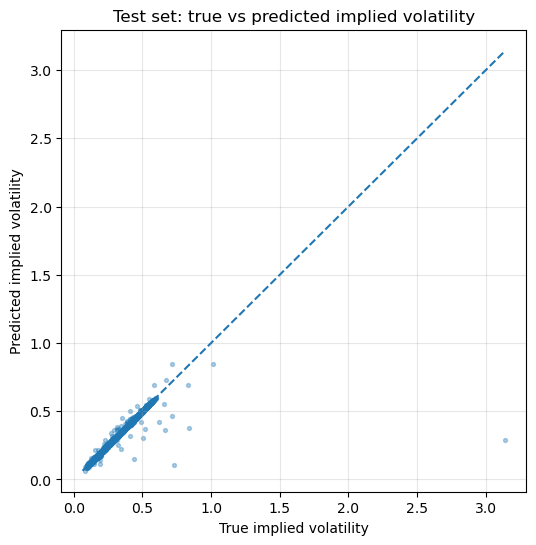

In [15]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test_raw[:, 0], test_pred[:, 0], s=8, alpha=0.35)

low = min(y_test_raw[:, 0].min(), test_pred[:, 0].min())
high = max(y_test_raw[:, 0].max(), test_pred[:, 0].max())

plt.plot([low, high], [low, high], linestyle="--")

plt.xlabel("True implied volatility")
plt.ylabel("Predicted implied volatility")
plt.title("Test set: true vs predicted implied volatility")
plt.grid(alpha=0.3)
plt.show()


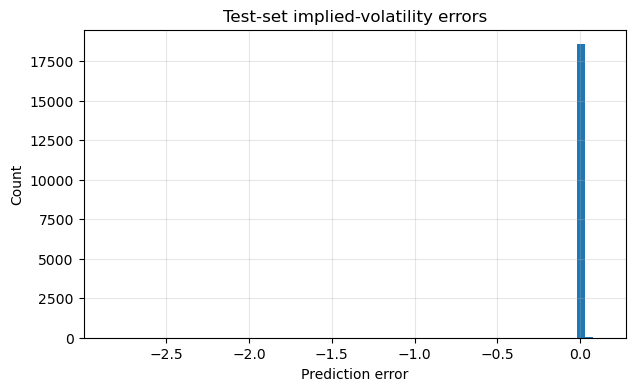

In [16]:
plt.figure(figsize=(7, 4))
plt.hist(test_errors[:, 0], bins=60)
plt.xlabel("Prediction error")
plt.ylabel("Count")
plt.title("Test-set implied-volatility errors")
plt.grid(alpha=0.3)
plt.show()


## 12. Check errors by maturity and moneyness

This helps identify where the emulator struggles.

Short maturities and deep in/out-of-the-money regions are often harder.


In [17]:
test_results = pd.DataFrame(X_test_raw, columns=feature_columns)
test_results["true_iv"] = y_test_raw[:, 0]
test_results["predicted_iv"] = test_pred[:, 0]
test_results["error"] = test_results["predicted_iv"] - test_results["true_iv"]
test_results["absolute_error"] = np.abs(test_results["error"])

maturity_error = (
    test_results
    .groupby("maturity")["absolute_error"]
    .mean()
    .reset_index()
)

moneyness_error = (
    test_results
    .groupby("moneyness")["absolute_error"]
    .mean()
    .reset_index()
)

display(maturity_error)
display(moneyness_error)


,maturity,absolute_error
0,0.005479,0.004176
1,0.010959,0.005098
2,0.019178,0.002560
3,0.027397,0.001639
4,0.035616,0.001537
5,0.057534,0.001501
6,0.082192,0.001633
7,0.164384,0.001689
8,0.246575,0.001691
9,0.493151,0.001657


,moneyness,absolute_error
0,0.70,0.002386
1,0.75,0.001922
2,0.80,0.001571
3,0.85,0.001576
4,0.90,0.001398
5,0.95,0.001380
6,1.00,0.001447
7,1.05,0.002226
8,1.10,0.003491
9,1.15,0.002126


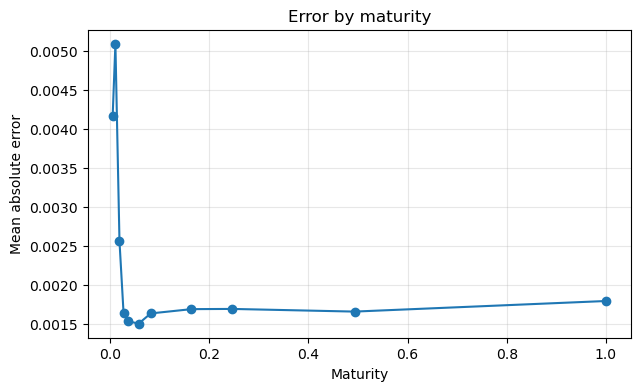

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(maturity_error["maturity"], maturity_error["absolute_error"], marker="o")
plt.xlabel("Maturity")
plt.ylabel("Mean absolute error")
plt.title("Error by maturity")
plt.grid(alpha=0.3)
plt.show()


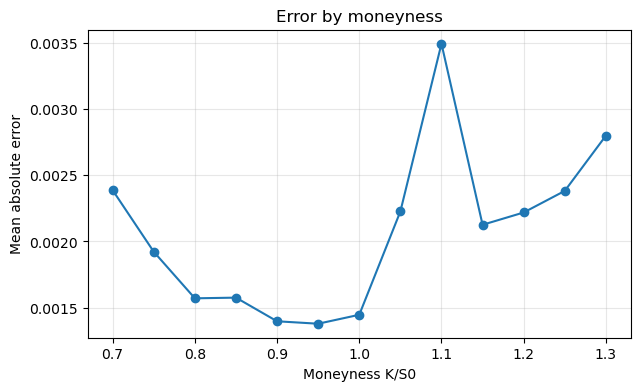

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(moneyness_error["moneyness"], moneyness_error["absolute_error"], marker="o")
plt.xlabel("Moneyness K/S0")
plt.ylabel("Mean absolute error")
plt.title("Error by moneyness")
plt.grid(alpha=0.3)
plt.show()


## 13. Save the trained emulator

The saved file includes:

- model weights,
- input normalization,
- target normalization,
- feature column order.

You need all of these to make predictions later.


In [20]:
SAVE_PATH = Path("heston_iv_neural_network.pt")

torch.save(
    {
        "model_state_dict": net.state_dict(),
        "feature_columns": feature_columns,
        "target_column": target_column,
        "X_mean": X_mean,
        "X_std": X_std,
        "y_mean": y_mean,
        "y_std": y_std,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
    },
    SAVE_PATH,
)

print(f"Saved trained model to {SAVE_PATH}")


Saved trained model to heston_iv_neural_network.pt


## 14. Example: predict one new IV point

Use this as a template for predicting a new implied volatility.


In [21]:
new_point = np.array([
    0.04,   # v0
    1.50,   # kappa
    0.04,   # theta
    0.40,   # sigma_v
    -0.60,  # rho
    1.00,   # moneyness
    30 / 365,  # maturity
], dtype=np.float32)

new_iv = predict_implied_volatility(net, new_point)

print("Predicted implied volatility:", new_iv[0, 0])


Predicted implied volatility: 0.20234074
